# EMG Characterization Offline Analysis — Phase 0: Setup & Configuration

This notebook is a full rewrite of the EMG characterization offline analysis. Phase 0 loads
required libraries, defines constants and configuration, and provides a UI to select a session
folder and the processing protocol (Online Filtering or Offline Filtering). We will adopt the
file/data handling patterns from `Respiration_offline.ipynb` and `Plot_1_Online_Diff.ipynb` /
`Plot_2_Offline_FWD_Filt.ipynb` as we proceed.


In [1]:
# Phase 0: Imports and Constants
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
from open_ephys.analysis import Session
from scipy.signal import butter, filtfilt, lfilter
import json
from pathlib import Path
from collections import defaultdict

# Processing protocols
PROTOCOL_ONLINE = "Online Filtering"
PROTOCOL_OFFLINE = "Offline Filtering"
PROTOCOL_OPTIONS = [PROTOCOL_ONLINE, PROTOCOL_OFFLINE]
DEFAULT_PROTOCOL = PROTOCOL_ONLINE

# Binning & trial constants (from Todo)
BIN_DURATION_MS = 50
SAMPLE_RATE_HINT = 5000  # default hint; overwritten by session metadata when available
BIN_SAMPLE_COUNT = int((SAMPLE_RATE_HINT / 1000) * BIN_DURATION_MS)

TRIAL_INIT_MIN_MS = 2200
TRIAL_INIT_MAX_MS = 2700
TRIAL_INIT_MIN_UV = 5.0
TRIAL_INIT_MAX_UV = 300.0

# Default directory
DEFAULT_DATA_DIR = os.getcwd()

print("Phase 0: imports and constants loaded. Default protocol:", DEFAULT_PROTOCOL)


Phase 0: imports and constants loaded. Default protocol: Online Filtering


In [2]:
# Phase 0: Session selection UI and helpers
# Widgets for selecting a session folder and processing protocol
dir_text = widgets.Text(value=DEFAULT_DATA_DIR, description='Session dir:', layout=widgets.Layout(width='70%'))
protocol_dropdown = widgets.Dropdown(options=PROTOCOL_OPTIONS, value=DEFAULT_PROTOCOL, description='Protocol:')
#recordnode_dropdown = widgets.Dropdown(options=[], description='Record Node:')
recordnode_dropdown = widgets.Dropdown(
    options=[],
    description='Record Node:',
    layout=widgets.Layout(
        width='300px',
        overflow='visible'
    )
)

load_button = widgets.Button(description='Load Session', button_style='primary')
output = widgets.Output(layout={'border': '1px solid gray'})

# Helper to scan the on-disk session tree for experiments/recordings
def scan_experiment_structure(session_dir, record_node_name="Record Node 106"):
    node_path = os.path.join(session_dir, record_node_name)
    if not os.path.exists(node_path):
        return {}
    experiment_info = defaultdict(list)
    for item in sorted(os.listdir(node_path)):
        exp_path = os.path.join(node_path, item)
        if os.path.isdir(exp_path) and item.startswith("experiment"):
            recordings = [r for r in sorted(os.listdir(exp_path)) 
                          if os.path.isdir(os.path.join(exp_path, r)) and r.startswith("recording")]
            experiment_info[item] = recordings
    return experiment_info

# Load handler
def on_load_clicked(b):
    with output:
        clear_output()
        directory = dir_text.value.strip()
        if not directory:
            print("Please enter a session directory.")
            return
        # Try to create a Session (preferred) - falls back to filesystem scan if unavailable
        try:
            s = Session(directory)
            globals()['session'] = s
            print("Session object loaded from:", directory)
            # Try to enumerate recordnodes when available
            try:
                nodes = [rn.name for rn in s.recordnodes]
            except Exception:
                nodes = []
            if nodes:
                recordnode_dropdown.options = nodes
                recordnode_dropdown.value = nodes[0]
            else:
                print("No `recordnodes` attribute on Session object; using common defaults.")
                recordnode_dropdown.options = ["Record Node 106", "Record Node 111"]

            # Scan on-disk structure for experiments & recordings
            structure = scan_experiment_structure(directory, recordnode_dropdown.value)
            globals()['structure'] = structure
            print("Found experiments:", list(structure.keys()))

            # Flatten experiment/recording pairs
            flat = []
            for exp, recs in structure.items():
                for r in recs:
                    flat.append((exp, r))
            globals()['flat_recordings'] = flat
            print(f"Discovered {len(flat)} recordings (showing up to 20):", [f"{e}/{r}" for e,r in flat[:20]])

        except Exception as e:
            print("Warning: could not create Session object. Falling back to filesystem scan.", e)
            structure = scan_experiment_structure(directory, recordnode_dropdown.value)
            globals()['structure'] = structure
            print("Found experiments (filesystem):", list(structure.keys()))

load_button.on_click(on_load_clicked)

# Display controls
controls = widgets.HBox([dir_text, protocol_dropdown, load_button])
print('Phase 0 UI: Specify the session folder and protocol, then click "Load Session"')

display(controls)
display(recordnode_dropdown)
display(output)


Phase 0 UI: Specify the session folder and protocol, then click "Load Session"


Phase 0 UI: Specify the session folder and protocol, then click "Load Session"


Phase 0 UI: Specify the session folder and protocol, then click "Load Session"


Dropdown(description='Record Node:', layout=Layout(overflow='visible', width='300px'), options=(), value=None)

Output(layout=Layout(border_bottom='1px solid gray', border_left='1px solid gray', border_right='1px solid gra…

# Set up Imports and Libraries

In [3]:
# === Import Necessary Libraries ===
# These are core scientific Python tools for data analysis and visualization.

import matplotlib.pyplot as plt
import numpy as np
from open_ephys.analysis import Session
import os
import re
from scipy.signal import butter, filtfilt, lfilter
from collections import defaultdict
import scipy.stats as stats


# 1. Selecting and Exploring a Recording Session

Open Ephys organizes experiments into “sessions,” each with one or more Record Nodes.
Here we select which node to analyze and define which session directory to load.

----------------

### Node Selection Raw vs. Filtered Node in Open Ephys

In this section we define a few arbitrary floating variables for processing purposes to help us select the right recording nodes we want, these variables will be "w", and "u".

#### In this case...

##### **NODE 111 = The RAW Node with Raw-unfiltered data** (Index = 0)

##### **NODE 106 = The FILTERD Node with Online-filtered data.** (Index = 1)

> Setting "u" and "w" equal to zero, wll result in selecting the first node **(0 = Record Node 106/RAW)**

> Setting "u" and "w" equal to one, wll result in selecting the second node **(1 = Record Node 111/FILTERED)**

In [4]:
# ==== Session Selection ====
w = 0  # Record Node index (0 = Record Node 106)
u = 0  # Record Node index (unused, reserved for alternate node, set to same as "w")

### Function: Scanning Experiment Structure

We’ll define a helper function to automatically list all experiments and recordings inside a session directory.

In [5]:
def scan_experiment_structure(session_dir, record_node_name="Record Node 106"):
    """
    Scans a given Open Ephys session directory and returns a dictionary of 
    experiment names and their associated recordings.
    """
    node_path = os.path.join(session_dir, record_node_name)
    
    if not os.path.exists(node_path):
        print(f"Record Node directory not found: {node_path}")
        return {}
    
    experiment_info = defaultdict(list)
    for item in sorted(os.listdir(node_path)):
        exp_path = os.path.join(node_path, item)
        if os.path.isdir(exp_path) and item.startswith("experiment"):
            recordings = [r for r in sorted(os.listdir(exp_path)) 
                          if os.path.isdir(os.path.join(exp_path, r)) and r.startswith("recording")]
            experiment_info[item] = recordings
    return experiment_info


# 2. Loading the Session Data

Now let’s point Python to a specific Open Ephys session directory and create a Session object.

In [26]:
# ==== Load Session ====
directory = 'HRPilot-05_FirstChronicTest1_2025-08-27_17-17-00_001'

session = Session(directory)
print('✅ Pass Initial Test, Moving on to Loading Session...\n')

✅ Pass Initial Test, Moving on to Loading Session...



### Scanning the Session's Structure

> Observe how the floating variable "w" we previously defined earlier is used here to 

In [6]:
record_node_name = "Record Node 106" if w == 0 else "Record Node 111"
structure = scan_experiment_structure(directory, record_node_name)

# Flatten all experiment-recording pairs
flat_recordings = []
for exp_name, rec_list in structure.items():
    for rec in rec_list:
        flat_recordings.append((exp_name, rec))

print(f"Found {len(flat_recordings)} recordings across {len(structure)} experiments.")


NameError: name 'directory' is not defined

In [7]:

# Phase 1: Recording selection and metadata loading
from ipywidgets import Button, Output, Dropdown

# Make options from flat_recordings if available
try:
    rec_options = [f"{i}: {e}/{r}" for i,(e,r) in enumerate(flat_recordings)]
except Exception:
    rec_options = []

recording_dropdown = Dropdown(options=rec_options, description='Recording:')
load_recording_button = Button(description='Open Recording', button_style='primary')
rec_output = Output()


def on_open_recording(b):
    with rec_output:
        clear_output()
        if not recording_dropdown.options:
            print("No recordings discovered. Use the 'Load Session' button in Phase 0 and select a record node.")
            return
        sel = recording_dropdown.value
        idx = int(str(sel).split(':',1)[0])
        try:
            # Try to fetch recording from Session object
            recording = session.recordnodes[w].recordings[idx]
            globals()['recording'] = recording
            print("Loaded recording:", recording)
            directory_str = recording.directory
            globals()['directory_str'] = directory_str

            parts = directory_str.split(os.sep)
            record_node_name = parts[-3]
            experiment_name  = parts[-2]
            recording_name   = parts[-1]
            globals()['record_node_name'] = record_node_name
            globals()['experiment_name'] = experiment_name
            globals()['recording_name'] = recording_name

            # Extract continuous data and metadata
            stream = recording.continuous[0]
            metadata = stream.metadata
            globals()['sample_rate'] = metadata.sample_rate
            globals()['num_channels'] = metadata.num_channels
            globals()['channel_names'] = metadata.channel_names

            print(f"Sample rate: {metadata.sample_rate} Hz | Channels: {metadata.num_channels} | Names: {metadata.channel_names}")

            # Update BIN_SAMPLE_COUNT based on actual sample_rate
            global BIN_SAMPLE_COUNT
            BIN_SAMPLE_COUNT = int((metadata.sample_rate / 1000) * BIN_DURATION_MS)
            print(f"BIN_SAMPLE_COUNT set to {BIN_SAMPLE_COUNT} samples")

            # Preload full data (be careful on large datasets)
            timestamps = stream.timestamps
            n_timestamps = timestamps.shape[0]
            data = stream.get_samples(start_sample_index=0, end_sample_index=n_timestamps)
            globals()['timestamps'] = timestamps
            globals()['data'] = data
            print("Data shape:", data.shape)

        except Exception as e:
            print("Error loading recording:", e)

load_recording_button.on_click(on_open_recording)

display(recording_dropdown, load_recording_button, rec_output)


Dropdown(description='Recording:', options=('0: experiment1/recording1',), value='0: experiment1/recording1')

Dropdown(description='Recording:', options=('0: experiment1/recording1',), value='0: experiment1/recording1')

Button(button_style='primary', description='Open Recording', style=ButtonStyle())

Output()

Applied offline bandpass (100.0-1000.0 Hz) using filtfilt at 5000.0 Hz


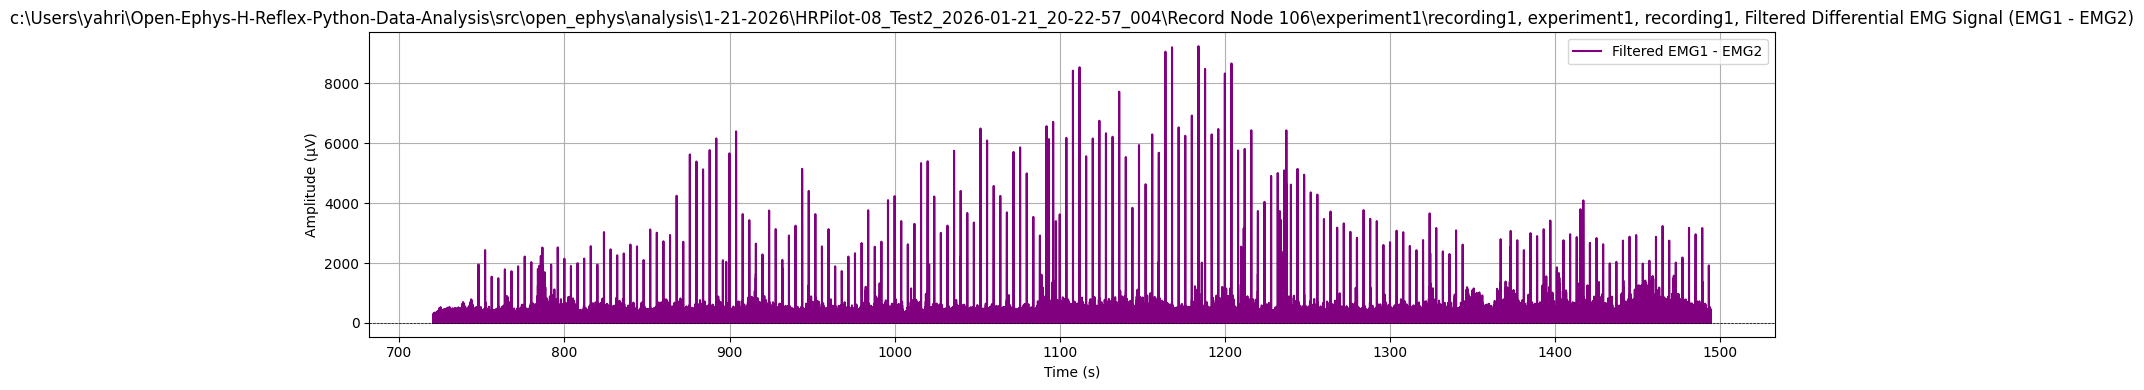

In [18]:

# Phase 1: EMG processing and full-trace plotting (protocol-aware)
from scipy.signal import butter, filtfilt, lfilter

try:
    timestamps
    data
except NameError:
    print("No recording data loaded. Please open a recording first.")
else:
    protocol = protocol_dropdown.value

    # Channel map (respiration example uses 2/3 for EMG channels)
    emg1_raw = data[:, 2]
    emg2_raw = data[:, 3]

    if protocol == PROTOCOL_ONLINE:
        # If online filtered, the data might already be filtered on channel 3
        differential_filt = data[:, 3]
        print("Using Online Filtering: assuming channel 3 is prefiltered differential EMG")
    else:
        # Offline filtering: compute diff then apply bandpass
        differential = (emg2_raw - emg1_raw)
        lowcut = 100.0
        highcut = 1000.0
        sample_rate = globals().get('sample_rate', SAMPLE_RATE_HINT)
        b, a = butter(2, np.array([lowcut, highcut])/(sample_rate/2), btype='bandpass')
        # Use filtfilt for zero-phase filtering
        differential_filt = lfilter(b, a, differential)
        print(f"Applied offline bandpass ({lowcut}-{highcut} Hz) using filtfilt at {sample_rate} Hz")

    differential_abs = np.abs(differential_filt)
    differential_emg = differential_abs

    plt.figure(figsize=(15, 4))
    plt.plot(timestamps, differential_emg, label="Filtered EMG1 - EMG2", color='purple')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
    plt.title(f"{directory_str}, {experiment_name}, {recording_name}, Filtered Differential EMG Signal (EMG1 - EMG2)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (μV)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [19]:
# Phase 1: Segment navigation UI (view long recordings in short windows)
segment_duration = 10  # seconds
try:
    total_time = timestamps[-1] - timestamps[0]
    num_segments = int(np.ceil(total_time / segment_duration))
    current_segment = 0

    from ipywidgets import Button, VBox
    output_segment = Output()

    def plot_segment(segment_idx):
        start_time = timestamps[0] + segment_idx * segment_duration
        end_time = min(start_time + segment_duration, timestamps[-1])
        mask = (timestamps >= start_time) & (timestamps < end_time)
        plt.figure(figsize=(15, 4))
        plt.plot(timestamps[mask] - start_time, differential_emg[mask], label="Filtered EMG", color='purple')
        # show blanking regions if available
        try:
            if 'blank_mask' in globals():
                # overlay shaded regions where blank_mask is False
                blank_mask_seg = ~blank_mask[mask]
                if blank_mask_seg.any():
                    # find contiguous runs and shade
                    idxs = np.where(mask)[0]
                    runs = []
                    run_start = None
                    for local_i, global_idx in enumerate(idxs):
                        if blank_mask_seg[local_i] and run_start is None:
                            run_start = timestamps[global_idx] - start_time
                        if (not blank_mask_seg[local_i] or local_i == len(idxs)-1) and run_start is not None:
                            run_end = timestamps[global_idx] - start_time
                            runs.append((run_start, run_end))
                            run_start = None
                    for s,e in runs:
                        plt.axvspan(s, e, color='red', alpha=0.25)
        except Exception:
            pass

        plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
        # compute and show blank fraction in this segment if available
        seg_blank_frac = 0.0
        if 'blank_mask' in globals():
            try:
                seg_mask = blank_mask[mask]
                seg_blank_frac = 1.0 - (np.sum(seg_mask) / float(seg_mask.size)) if seg_mask.size>0 else 0.0
            except Exception:
                seg_blank_frac = 0.0
        plt.title(f"{directory_str}, {experiment_name}, {recording_name}, Segment {segment_idx+1}/{num_segments} | Time: {start_time:.1f}-{end_time:.1f}s | blank={seg_blank_frac:.2%}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude (μV)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def on_next(b):
        global current_segment
        if current_segment < num_segments - 1:
            current_segment += 1
            with output_segment:
                output_segment.clear_output(wait=True)
                plot_segment(current_segment)

    def on_prev(b):
        global current_segment
        if current_segment > 0:
            current_segment -= 1
            with output_segment:
                output_segment.clear_output(wait=True)
                plot_segment(current_segment)

    next_button = Button(description="Next")
    prev_button = Button(description="Previous")
    next_button.on_click(on_next)
    prev_button.on_click(on_prev)

    # Initial plot
    with output_segment:
        plot_segment(current_segment)

    display(VBox([prev_button, next_button, output_segment]))

except Exception as e:
    print("Could not set up segment navigation:", e)


In [20]:

# Phase 1: Load MessageCenter (events/messages) for stim timing and triggers
try:
    messagecenter_dir = os.path.join(directory_str.split(os.sep)[-3], record_node_name, experiment_name, recording_name, "events", "MessageCenter")
    # The above path attempt may be redundant if messagecenter already at os.path.join(directory_str, 'events', 'MessageCenter')
    if not os.path.exists(messagecenter_dir):
        # try simple: directory_str + events
        messagecenter_dir = os.path.join(directory_str, 'events', 'MessageCenter')

    if not os.path.exists(messagecenter_dir):
        print(f"MessageCenter directory not found: {messagecenter_dir}")
    else:
        texts = np.load(os.path.join(messagecenter_dir, "text.npy"), allow_pickle=True)
        timestamps_msg = np.load(os.path.join(messagecenter_dir, "timestamps.npy"))
        decoded_texts = [t.decode('utf-8') if isinstance(t, bytes) else str(t) for t in texts]
        message_entries = list(zip(timestamps_msg, decoded_texts))
        print(f"Loaded {len(decoded_texts)} MessageCenter entries from {messagecenter_dir}")
        # Debug print (first 20)
        for t, txt in message_entries[:20]:
            print(f"[Time: {t:.6f} s] Message: {txt}")

except Exception as e:
    print("MessageCenter load error:", e)


Loaded 213 MessageCenter entries from c:\Users\yahri\Open-Ephys-H-Reflex-Python-Data-Analysis\src\open_ephys\analysis\1-21-2026\HRPilot-08_Test2_2026-01-21_20-22-57_004\Record Node 106\experiment1\recording1\events\MessageCenter
[Time: 735.658600 s] Message: Pico In
[Time: 743.497800 s] Message: Starting at 0.10 mA
[Time: 747.933600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 751.948800 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 755.925600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 759.940800 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 763.956000 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 767.933000 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 771.948200 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 773.057200 s] Message: Starting at 0.15 mA
[Time: 775.925200 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 779.940400 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 783.955400 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 787.932400 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time:

# Phase 2 — Blanking, Binning and Trial Sweep

This phase implements the robust sample-based "blanking" (throw-out) around event markers and provides the trial sweep / binning pipeline for offline processing. Key design points:

- Convert trigger times to sample indices to create a binary `blank_mask` (True=valid sample, False=blanked).
- Use configurable blank window (default: 10 ms pre, 50 ms post) converted to samples via the recording's sample rate.
- Implement `compute_bin_means` and `grand_mean_from_bins` that respect the blank mask and require a `min_valid_fraction` per bin.
- Implement a `sweep_trials` function that walks through the recording, picks randomized trial durations within [TRIAL_INIT_MIN_MS, TRIAL_INIT_MAX_MS] (rounded to `BIN_DURATION_MS` multiples), and saves trials that pass the mean-amplitude acceptance criteria.

All functions are vectorized where practical and are documented in-line. The results will be saved into a `trials` list with metadata for later inspection or export.

Found 181 trigger messages
Blank mask created: 181 events -> 54481 samples blanked (0.0141 fraction)
Sweep complete. Collected 315 accepted trials.
Trial 0: start=0 end=13250 dur_ms=2650 grand_mean=63.83
Trial 1: start=13250 end=25250 dur_ms=2400 grand_mean=83.03
Trial 2: start=25250 end=38250 dur_ms=2600 grand_mean=98.11


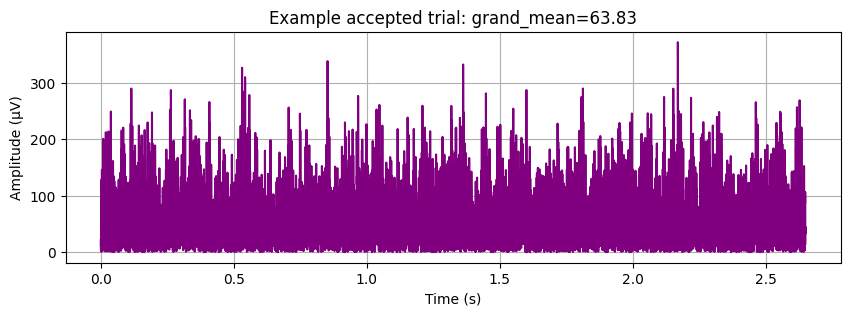

In [21]:
# Phase 2: Blanking (sample-based), binning utilities, and trial sweep
# Convert message triggers to sample indices, build a sample-accurate blank mask,
# then sweep through the recording and collect trials that meet the acceptance criteria.

# Parameters (ms)
blank_pre_ms = 10    # ms before event
blank_post_ms = 50   # ms after event
min_valid_fraction = 0.7  # require >=70% valid samples per bin

# Helper: parse trigger times from MessageCenter (RHDCONTROL TRIGGER)
trigger_pattern = re.compile(r"RHDCONTROL TRIGGER", re.IGNORECASE)
trigger_times = []
try:
    for t, msg in message_entries:
        if trigger_pattern.search(msg):
            trigger_times.append(float(t))
    trigger_times = sorted(trigger_times)
    print(f"Found {len(trigger_times)} trigger messages")
except Exception as e:
    print("No message_entries available or parsing error:", e)
    trigger_times = []

# If possible use `recording.continuous[0].metadata.sample_rate`
sample_rate = globals().get('sample_rate', SAMPLE_RATE_HINT)

# Convert trigger times to nearest sample indices
try:
    trig_sample_idxs = np.searchsorted(timestamps, np.array(trigger_times))
except Exception:
    trig_sample_idxs = np.array([], dtype=int)

# Convert ms -> samples
pre_samples = int(np.ceil(blank_pre_ms * sample_rate / 1000.0))
post_samples = int(np.ceil(blank_post_ms * sample_rate / 1000.0))

# Build blank_mask (True=keep, False=blank)
try:
    n = len(timestamps)
    blank_mask = np.ones(n, dtype=bool)
    for idx in trig_sample_idxs:
        s = max(0, int(idx - pre_samples))
        e = min(n, int(idx + post_samples) + 1)
        blank_mask[s:e] = False
    globals()['blank_mask'] = blank_mask
    print(f"Blank mask created: {len(trig_sample_idxs)} events -> {np.sum(~blank_mask)} samples blanked ({(np.sum(~blank_mask)/n):.4f} fraction)")
except Exception as e:
    print("Could not create blank mask:", e)

# Utilities for bins & trials

def compute_bin_means(signal: np.ndarray, blank_mask: np.ndarray, bin_sample_count: int):
    """Compute non-overlapping bin means and per-bin valid fraction.
    Trims excess samples at the end to keep full bins only."""
    n = len(signal)
    n_full = (n // bin_sample_count) * bin_sample_count
    if n_full == 0:
        return np.array([]), np.array([])
    sig = signal[:n_full]
    mask = blank_mask[:n_full]
    reshaped_sig = sig.reshape(-1, bin_sample_count)
    reshaped_mask = mask.reshape(-1, bin_sample_count)
    valid_counts = reshaped_mask.sum(axis=1)
    # compute means only using valid samples; invalid bins remain nan
    means = np.full((reshaped_sig.shape[0],), np.nan, dtype=np.float64)
    for i in range(reshaped_sig.shape[0]):
        if valid_counts[i] > 0:
            means[i] = reshaped_sig[i, reshaped_mask[i]].mean()
    valid_frac = valid_counts / float(bin_sample_count)
    return means, valid_frac


def grand_mean_from_bins(bin_means: np.ndarray, valid_frac: np.ndarray, min_valid_fraction: float):
    mask = (valid_frac >= min_valid_fraction) & (~np.isnan(bin_means))
    if np.sum(mask) == 0:
        return np.nan
    return float(np.mean(bin_means[mask]))


def round_to_nearest_multiple(x: int, base: int = BIN_DURATION_MS) -> int:
    return int(base * round(x / base))


# Trial sweep function: sequentially walk through recording, generate random trial durations,
# compute trial grand mean using blanking and accept trial if grand mean in initiation bounds.
from random import Random
_rng = Random(0)


def sweep_trials(signal: np.ndarray,
                 timestamps: np.ndarray,
                 blank_mask: np.ndarray,
                 sample_rate: float,
                 min_ms: int = TRIAL_INIT_MIN_MS,
                 max_ms: int = TRIAL_INIT_MAX_MS,
                 min_uv: float = TRIAL_INIT_MIN_UV,
                 max_uv: float = TRIAL_INIT_MAX_UV,
                 bin_duration_ms: int = BIN_DURATION_MS,
                 min_valid_fraction_local: float = min_valid_fraction):
    trials = []
    n = len(signal)
    i = 0
    bin_sample_count = int(np.round(bin_duration_ms * sample_rate / 1000.0))
    if bin_sample_count <= 0:
        raise ValueError('BIN_SAMPLE_COUNT computed as 0. Check sample_rate and BIN_DURATION_MS')

    while i < n:
        dur_ms = _rng.randint(min_ms, max_ms)
        dur_ms = round_to_nearest_multiple(dur_ms, base=bin_duration_ms)
        dur_samples = int(np.round(dur_ms * sample_rate / 1000.0))
        if i + dur_samples > n:
            break
        seg = signal[i:i+dur_samples]
        seg_mask = blank_mask[i:i+dur_samples]
        # compute bin stats for this candidate trial
        bin_means, valid_frac = compute_bin_means(seg, seg_mask, bin_sample_count)
        gm = grand_mean_from_bins(bin_means, valid_frac, min_valid_fraction_local)
        # Acceptance check
        if (not np.isnan(gm)) and (min_uv <= gm <= max_uv):
            trials.append({'start_sample': i,
                           'end_sample': i+dur_samples,
                           'dur_ms': dur_ms,
                           'bin_means': bin_means,
                           'valid_frac': valid_frac,
                           'grand_mean': gm})
            # advance by trial duration (non-overlapping)
            i += dur_samples
        else:
            # advance by one bin to resample starting point
            i += bin_sample_count
    return trials

# Run sweep example (be careful on big recordings)
try:
    trials = sweep_trials(differential_emg, timestamps, blank_mask, sample_rate)
    print(f"Sweep complete. Collected {len(trials)} accepted trials.")
    # Display first 3 trials summary
    for k,t in enumerate(trials[:3]):
        print(f"Trial {k}: start={t['start_sample']} end={t['end_sample']} dur_ms={t['dur_ms']} grand_mean={t['grand_mean']:.2f}")

    # Show an example accepted trial plot
    if len(trials) > 0:
        t0 = trials[0]
        s = t0['start_sample']
        e = t0['end_sample']
        plt.figure(figsize=(10,3))
        plt.plot(timestamps[s:e] - timestamps[s], differential_emg[s:e], color='purple')
        # shaded blanked regions inside trial
        blank_local = ~blank_mask[s:e]
        if blank_local.any():
            idxs = np.where(blank_local)[0]
            # find contiguous runs
            runs = []
            run_start = None
            prev_idx = None
            for pos in idxs:
                if run_start is None:
                    run_start = timestamps[s+pos] - timestamps[s]
                    prev_idx = pos
                elif pos != prev_idx + 1:
                    run_end = timestamps[s+prev_idx] - timestamps[s]
                    runs.append((run_start, run_end))
                    run_start = timestamps[s+pos] - timestamps[s]
                    prev_idx = pos
                else:
                    prev_idx = pos
            if run_start is not None:
                run_end = timestamps[s+prev_idx] - timestamps[s]
                runs.append((run_start, run_end))
            for rs,re in runs:
                plt.axvspan(rs, re, color='red', alpha=0.25)
        plt.title(f"Example accepted trial: grand_mean={t0['grand_mean']:.2f}")
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude (μV)')
        plt.grid(True)
        plt.show()

except Exception as e:
    print("Trial sweep example skipped (missing data):", e)


## Phase 2b — MH-style histogram: trial grand-means + cleaned-sample histogram 📊

This cell computes a histogram that matches the style used by `MhRecruitmentCurveStage`:

- **Primary histogram (left):** assembled *trial grand-means* (one value per accepted trial). Bins use a **1% step-size** across the primary min→max range (i.e., ~100 bins). Heights are raw **counts** (not density), and the plot includes vertical initiation-threshold lines.
- **Secondary histogram (right):** cleaned *sample-level* amplitudes (blanked samples removed) for diagnostic purposes.

Features:
- Dynamic titles/labels showing recording name, number of trials/samples, and fraction blanked. ✅
- Optional `yscale` (linear or log), and options to save PNG/JSON of histogram data.
- Exposes computed stats and arrays to the notebook namespace for downstream use (see `hist_out`, `hist_primary_stats`, etc.).

Run the histogram cell after Phase 2 to visualize the assembled binned-signal distribution and confirm initiation thresholds visually.

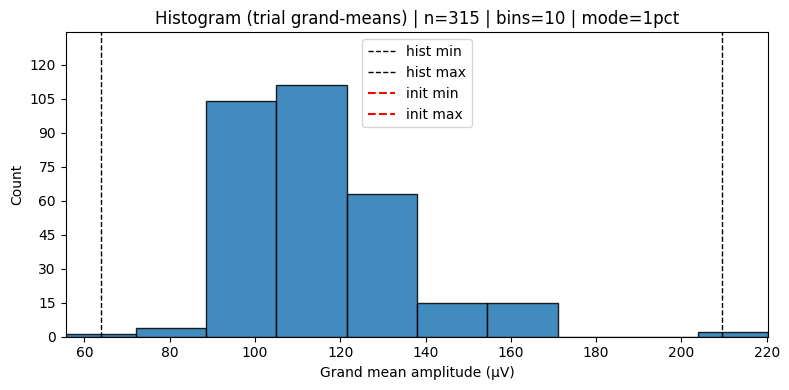

Histogram summary: n=315, min=63.828, max=209.463, step1%=16.481, mode=1pct


In [22]:
# Phase 2b: Histogram of trial grand-means (single panel)
import math

def compute_mh_style_histogram_and_stats(yscale='linear', save_png=False, save_json=False, num_bins=None, binning='1pct'):
    """Build an MH-style histogram of trial grand-means (single panel only).

    Returns: dict with keys: fig, ax, primary_stats, hist_vals, hist_edges, save_paths, binning
    """

    from matplotlib.ticker import MaxNLocator

    # Gather trial grand-means
    grand_means = np.array([])
    if 'trials' in globals() and len(trials) > 0:
        try:
            grand_means = np.array([float(t['grand_mean']) for t in trials])
            grand_means = grand_means[~np.isnan(grand_means)]
        except Exception:
            grand_means = np.array([])

    if grand_means.size == 0:
        print('No trial grand-means available; run sweep_trials() first.')
        fig, ax = plt.subplots(1,1,figsize=(7,4))
        ax.text(0.5,0.5,'No trial grand-means available', ha='center')
        plt.tight_layout()
        plt.show()
        primary_stats = {'n': 0}
        return {'fig': fig, 'ax': ax, 'primary_stats': primary_stats, 'hist_vals': np.array([]), 'hist_edges': np.array([]), 'save_paths': {}}

    # Compute primary stats
    mn = float(np.min(grand_means)); mx = float(np.max(grand_means)); n = int(grand_means.size)
    mean = float(np.mean(grand_means)); std_dev = float(np.std(grand_means, ddof=0))
    q25, q50, q75 = np.percentile(grand_means, [25,50,75])
    q1 = float(np.quantile(grand_means, 0.01)) if n>1 else mn
    step_one_percent = float(q1 - mn)
    if step_one_percent <= 0:
        step_one_percent = (mx - mn) / 100.0 if (mx - mn) > 0 else max(0.1, abs(mx)*0.01 if mx!=0 else 0.1)

    primary_stats = {'n': n, 'min': mn, 'max': mx, 'mean': mean, 'std_dev': std_dev, 'q25': q25, 'q50': q50, 'q75': q75, 'step_size_one_percent': step_one_percent}

    # Build histogram bins
    if binning == '1pct':
        step = step_one_percent
        edges = np.arange(mn - 0.5*step, mx + 1.5*step, step)
        if edges.size < 2:
            edges = np.linspace(mn - 0.5, mx + 0.5, 11)
        hist_vals, hist_edges = np.histogram(grand_means, bins=edges)
    elif binning == 'auto':
        hist_vals, hist_edges = np.histogram(grand_means, bins='auto')
    else:
        bins = 10 if num_bins is None else int(num_bins)
        hist_vals, hist_edges = np.histogram(grand_means, bins=bins)

    # Plot single panel
    fig, ax = plt.subplots(1,1, figsize=(8,4))
    centers = (hist_edges[:-1] + hist_edges[1:]) / 2.0
    widths = (hist_edges[1:] - hist_edges[:-1])
    ax.bar(centers, hist_vals, width=widths, align='center', color='C0', edgecolor='k', alpha=0.85)
    ax.set_xlabel('Grand mean amplitude (μV)')
    ax.set_ylabel('Count')
    ax.set_title(f'Histogram (trial grand-means) | n={n:,} | bins={len(hist_vals)} | mode={binning}')

    ax.set_xlim(hist_edges[0], hist_edges[-1])
    ax.axvline(mn, color='black', linestyle='--', linewidth=1.0, label='hist min')
    ax.axvline(mx, color='black', linestyle='--', linewidth=1.0, label='hist max')
    if 'TRIAL_INIT_MIN_UV' in globals():
        ax.axvline(TRIAL_INIT_MIN_UV, color='red', linestyle='--', linewidth=1.5, label='init min')
        ax.axvline(TRIAL_INIT_MAX_UV, color='red', linestyle='--', linewidth=1.5, label='init max')
    ax.legend()

    ymax = int(max(hist_vals)) if hist_vals.size>0 else 1
    ax.set_ylim(0, ymax*1.2 + 1)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    if yscale in ('log','symlog'):
        ax.set_yscale(yscale)

    plt.tight_layout()
    plt.show()

    # Save if requested (primary histogram only)
    save_paths = {}
    if save_png and 'directory_str' in globals() and 'recording_name' in globals():
        try:
            png_path = os.path.join(directory_str, f"{recording_name}_grandmeans_histogram.png")
            fig.savefig(png_path, dpi=150)
            save_paths['png'] = png_path
        except Exception as e:
            print('Could not save histogram PNG:', e)
    if save_json and hist_vals.size > 0 and 'directory_str' in globals() and 'recording_name' in globals():
        try:
            json_path = os.path.join(directory_str, f"{recording_name}_grandmeans_histogram.json")
            hist_dict = {'hist_vals': hist_vals.tolist(), 'hist_edges': hist_edges.tolist(), 'primary_stats': primary_stats, 'binning': binning}
            with open(json_path, 'w') as jf:
                json.dump(hist_dict, jf, indent=2)
            save_paths['json'] = json_path
        except Exception as e:
            print('Could not save histogram JSON:', e)

    print(f"Histogram summary: n={n}, min={mn:.3f}, max={mx:.3f}, step1%={step_one_percent:.3f}, mode={binning}")

    return {'fig': fig, 'ax': ax, 'primary_stats': primary_stats, 'hist_vals': hist_vals, 'hist_edges': hist_edges, 'save_paths': save_paths, 'binning': binning}


# Run updated histogram and store outputs (primary grand-means only)
hist_out = compute_mh_style_histogram_and_stats(yscale='linear')
# Expose fields to globals for downstream usage (primary only)
globals().update({
    'hist_primary_stats': hist_out.get('primary_stats', {}),
    'hist_values': hist_out.get('hist_vals', np.array([])),
    'hist_edges': hist_out.get('hist_edges', np.array([])),
})

### Phase 3 — Peri-stimulus extraction, grouping, and M/H detection 





In [43]:
# Phase 3: Peri-stimulus extraction, grouping, and M/H detection 

Extracted 181 peri-stimulus segments.
Found 28 stimulation amplitude groups with valid peri-stim data.
Computed average traces and picked M/H peaks for each amplitude (with SEM).


Extracted 181 peri-stimulus segments.
Found 28 stimulation amplitude groups with valid peri-stim data.
Computed average traces and picked M/H peaks for each amplitude (with SEM).


Phase 3 complete (iter3 fixed). Viewer ready; `amp_results` available for Phase 4.


## Phase 4 — Recruitment normalization and saving results

In this phase we normalize the M-wave amplitudes to M_max and compute the current corresponding to 50% M_max (interpolation). We also annotate H_max and the corresponding current. Results (trials and amplitude summaries) can be exported for downstream analysis.

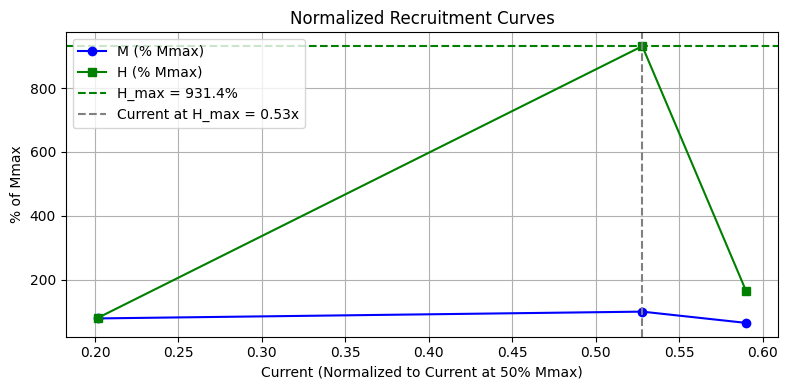

Saved recruitment summary to c:\Users\yahri\Open-Ephys-H-Reflex-Python-Data-Analysis\src\open_ephys\analysis\recruitment_summary_experiment1_recording1.json


In [28]:
# Phase 4: Normalize recruitment curves and save results
from scipy.interpolate import interp1d
import json

if 'amp_results' not in globals() or len(amp_results)==0:
    print("No amplitude results available to normalize.")
else:
    amps_sorted = sorted(amp_results.keys())
    m_means = np.array([amp_results[a]['m_amp'] for a in amps_sorted])
    h_means = np.array([amp_results[a]['h_amp'] for a in amps_sorted])
    # Use absolute values
    m_means_abs = np.abs(m_means)
    h_means_abs = np.abs(h_means)

    M_max = np.max(m_means_abs)
    if M_max == 0:
        print("M_max is zero; cannot normalize.")
    else:
        m_norm = (m_means_abs / M_max) * 100.0
        h_norm = (h_means_abs / M_max) * 100.0

        # Interpolate to find current at 50% Mmax
        try:
            interp_func = interp1d(m_norm, amps_sorted, kind='linear', bounds_error=False, fill_value='extrapolate')
            current_at_50 = float(interp_func(50.0))
        except Exception:
            current_at_50 = np.nan

        H_max = np.nanmax(h_norm)
        idx_Hmax = int(np.nanargmax(h_norm)) if not np.all(np.isnan(h_norm)) else None
        current_at_Hmax_norm = (amps_sorted[idx_Hmax] / current_at_50) if (idx_Hmax is not None and not np.isnan(current_at_50) and current_at_50 != 0) else np.nan

        # Plot normalized curves
        plt.figure(figsize=(8,4))
        plt.plot(np.array(amps_sorted)/current_at_50, m_norm, 'o-', color='blue', label='M (% Mmax)')
        plt.plot(np.array(amps_sorted)/current_at_50, h_norm, 's-', color='green', label='H (% Mmax)')
        plt.axhline(H_max, color='green', linestyle='--', label=f'H_max = {H_max:.1f}%')
        if not np.isnan(current_at_Hmax_norm):
            plt.axvline(current_at_Hmax_norm, color='gray', linestyle='--', label=f'Current at H_max = {current_at_Hmax_norm:.2f}x')
        plt.xlabel('Current (Normalized to Current at 50% Mmax)')
        plt.ylabel('% of Mmax')
        plt.title('Normalized Recruitment Curves')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Save results
        results = {
            'amps_sorted': amps_sorted,
            'm_means_abs': m_means_abs.tolist(),
            'h_means_abs': h_means_abs.tolist(),
            'm_norm': m_norm.tolist(),
            'h_norm': h_norm.tolist(),
            'M_max': float(M_max),
            'H_max': float(H_max),
            'current_at_50': float(current_at_50)
        }
        save_path = os.path.join(DEFAULT_DATA_DIR, f"recruitment_summary_{experiment_name}_{recording_name}.json")
        try:
            with open(save_path, 'w') as f:
                json.dump(results, f, indent=2)
            print(f"Saved recruitment summary to {save_path}")
        except Exception as e:
            print("Could not save recruitment summary:", e)

# How to use this notebook — Quick run guide ✅

1. Phase 0: Enter your session directory and choose a protocol (Online/Offline). Click **Load Session**.  
2. Phase 1: Select a discovered recording and click **Open Recording**. Check the sample rate and channel names printed.  
3. Phase 1: Run the EMG processing cell — it will apply the chosen protocol (offline → bandpass via `filtfilt`, online → uses prefiltered channel).  
4. Phase 1: Use segment navigation to inspect long recordings.  
5. Phase 1: Run the MessageCenter loader to load `text.npy` and `timestamps.npy` used for trigger/stim messages.  
6. Phase 2: Run the blanking and binning cell — this creates `blank_mask` and runs an example trial sweep.  
7. Phase 3: Run peri-stim extraction and grouping by stimulation amplitude to compute averaged peri-stim EMG traces and detect M/H peaks.  
8. Phase 4: Run recruitment normalization and save the results as a JSON summary.  

Notes & tips:
- Adjust `blank_pre_ms` / `blank_post_ms` to tune how conservatively you exclude MEP-contaminated samples.  
- `min_valid_fraction` controls the required fraction of valid samples per bin; increase to be more strict.  
- For long recordings, avoid preloading everything into memory if you have low RAM — you can adapt the `sweep_trials` routine to operate on chunks.  

If you'd like, I can now:
- Add a ``Save trials`` cell (NPZ/CSV) and a small demo loader to reload and inspect saved trials, or
- Integrate this offline pipeline into the `emg_characterization_stage` class (for reuse in the GUI streaming pipeline), or
- Add automated tests for the helper functions.

Which would you like me to implement next?